In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

import time
import random

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:

import os
import matplotlib.pyplot as plt

# Folder for all final EPS plots
PLOT_DIR = "lab7_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Plot formatting
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.size"] = 15
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15



In [ ]:

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [ ]:


(x_train_full, y_train_full), (x_test_full, y_test_full) = \
    keras.datasets.mnist.load_data()

print("Full training set:", x_train_full.shape)
print("Full test set:", x_test_full.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full training set: (60000, 28, 28)
Full test set: (10000, 28, 28)


In [ ]:

TRAIN_SIZE = 10_000
TEST_SIZE = 2_000

x_train = x_train_full[:TRAIN_SIZE]
y_train = y_train_full[:TRAIN_SIZE]

x_test = x_test_full[:TEST_SIZE]
y_test = y_test_full[:TEST_SIZE]

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

Training images: (10000, 28, 28)
Test images: (2000, 28, 28)


In [ ]:

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:


x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (10000, 28, 28, 1)
Test shape: (2000, 28, 28, 1)


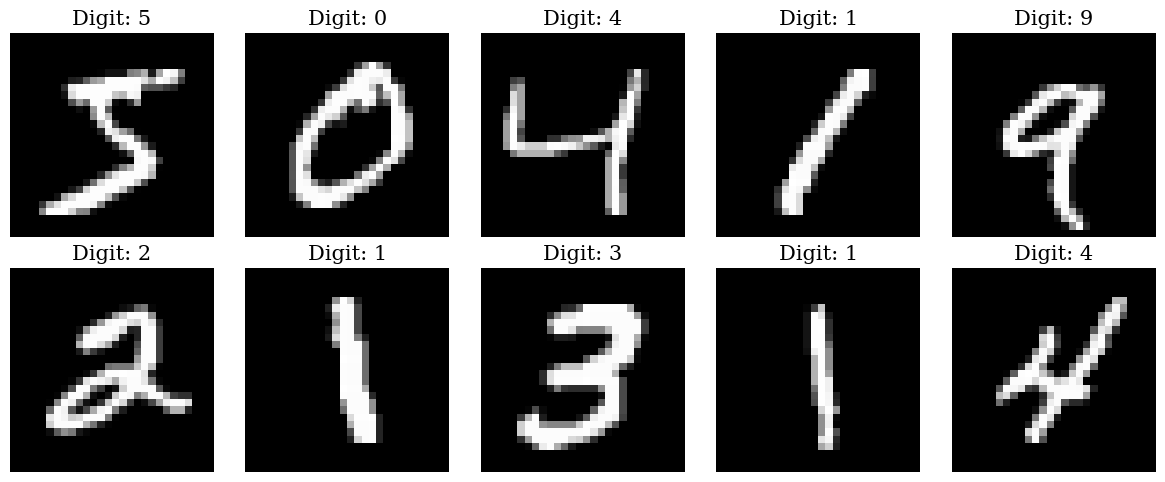

In [ ]:

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 2 — FULLY CONNECTED AUTOENCODER
# Prepare flattened images
# ============================================================

x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Training shape:", x_train_flat.shape)
print("Test shape:", x_test_flat.shape)

Training shape: (10000, 784)
Test shape: (2000, 784)


In [ ]:
# ============================================================
# Fully Connected Autoencoder
# ============================================================

latent_dim = 16

fc_autoencoder = keras.Sequential([
    layers.Input(shape=(784,)),

    # Encoder
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(latent_dim, activation="relu", name="latent"),

    # Decoder
    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
], name="Fully_Connected_Autoencoder")

fc_autoencoder.summary()

Model: "Fully_Connected_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Compile FC Autoencoder
# ============================================================

fc_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:

# Train FC Autoencoder

EPOCHS = 20
BATCH_SIZE = 128

start_time = time.time()

fc_history = fc_autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

fc_training_time = time.time() - start_time

print(f"\nTraining time: {fc_training_time:.2f} seconds")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.3654 - val_loss: 0.2550
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2355 - val_loss: 0.2235
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2057 - val_loss: 0.1936
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1829 - val_loss: 0.1791
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1711 - val_loss: 0.1697
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1621 - val_loss: 0.1613
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1546 - val_loss: 0.1552
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1492 - val_loss: 0.1508
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1454 - val_loss: 0.1477
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1425 - val_loss: 0.1453
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1401 - val_loss: 0.1434
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1380 - val_l

In [ ]:

# Generate FC-AE reconstructions


fc_reconstructed_flat = fc_autoencoder.predict(
    x_test_flat,
    batch_size=BATCH_SIZE,
    verbose=1
)

fc_reconstructed = fc_reconstructed_flat.reshape(
    -1, 28, 28, 1
)

print("Original shape:     ", x_test.shape)
print("Reconstructed shape:", fc_reconstructed.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Original shape:      (2000, 28, 28, 1)
Reconstructed shape: (2000, 28, 28, 1)


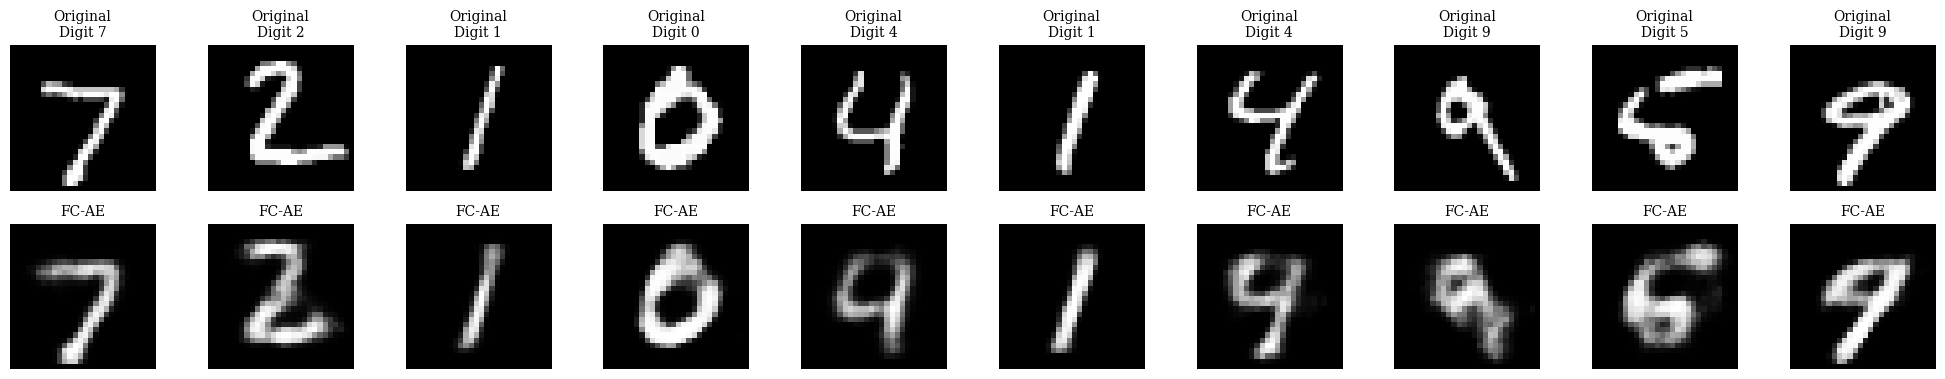

In [ ]:

fig, axes = plt.subplots(
    2, 10,
    figsize=(20, 4)
)

for i in range(10):

    # Original
    axes[0, i].imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    axes[0, i].set_title(
        f"Original\nDigit {y_test[i]}",
        fontsize=10
    )
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(
        fc_reconstructed[i].squeeze(),
        cmap="gray"
    )
    axes[1, i].set_title(
        "FC-AE",
        fontsize=10
    )
    axes[1, i].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_1_original_vs_reconstructed.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

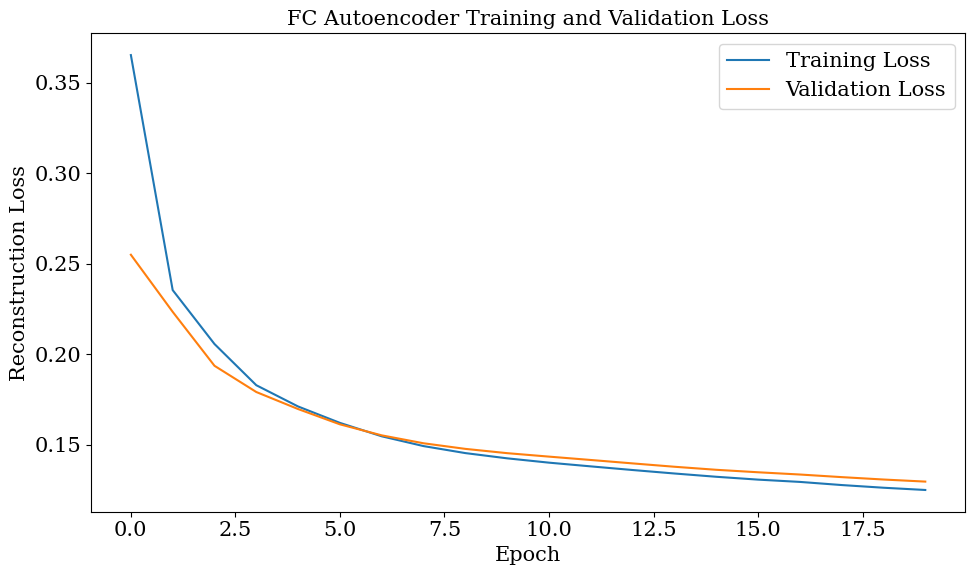

In [ ]:


plt.figure(figsize=(10, 6))

plt.plot(
    fc_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fc_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("FC Autoencoder Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_2_fc_training_validation_loss.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:

fc_test_mse = np.mean(
    (x_test - fc_reconstructed) ** 2
)

fc_test_mae = np.mean(
    np.abs(x_test - fc_reconstructed)
)

print(f"FC-AE Test MSE: {fc_test_mse:.6f}")
print(f"FC-AE Test MAE: {fc_test_mae:.6f}")

FC-AE Test MSE: 0.022520
FC-AE Test MAE: 0.059343


In [ ]:

fc_ssim_values = []

for i in range(len(x_test)):

    score = ssim(
        x_test[i].squeeze(),
        fc_reconstructed[i].squeeze(),
        data_range=1.0
    )

    fc_ssim_values.append(score)

fc_mean_ssim = np.mean(fc_ssim_values)

print(f"FC-AE Mean SSIM: {fc_mean_ssim:.6f}")

FC-AE Mean SSIM: 0.730456


In [ ]:


conv_autoencoder = keras.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),

    # Decoder
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        1, (3, 3),
        activation="sigmoid",
        padding="same"
    )

], name="Convolutional_Autoencoder")

conv_autoencoder.summary()

Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


conv_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

In [ ]:

start_time = time.time()

conv_history = conv_autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

conv_training_time = time.time() - start_time

print(f"\nCAE Training Time: {conv_training_time:.2f} seconds")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - loss: 0.2797 - val_loss: 0.1202
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1001 - val_loss: 0.0914
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0866 - val_loss: 0.0834
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0816 - val_loss: 0.0793
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0785 - val_loss: 0.0770
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0765 - val_loss: 0.0752
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0749 - val_loss: 0.0742
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0741 - val_loss: 0.0735
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0731 - val_loss: 0.0728
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0725 - val_loss: 0.0720
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0719 - val_loss: 0.0720
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0714 - val_l

In [ ]:
# ============================================================
# CAE RECONSTRUCTION
# ============================================================

conv_reconstructed = conv_autoencoder.predict(
    x_test,
    batch_size=128,
    verbose=1
)

print("Reconstruction shape:", conv_reconstructed.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Reconstruction shape: (2000, 28, 28, 1)


In [ ]:

conv_test_mse = np.mean(
    (x_test - conv_reconstructed) ** 2
)

conv_test_mae = np.mean(
    np.abs(x_test - conv_reconstructed)
)

print(f"CAE Test MSE : {conv_test_mse:.6f}")
print(f"CAE Test MAE : {conv_test_mae:.6f}")

CAE Test MSE : 0.002682
CAE Test MAE : 0.015420


In [ ]:


conv_ssim_values = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i].squeeze(),
        conv_reconstructed[i].squeeze(),
        data_range=1.0
    )
    conv_ssim_values.append(score)

conv_mean_ssim = np.mean(conv_ssim_values)

print(f"CAE Mean SSIM: {conv_mean_ssim:.6f}")
conv_params = conv_autoencoder.count_params()

print(f"CAE Parameters: {conv_params:,}")

CAE Mean SSIM: 0.972842
CAE Parameters: 74,497


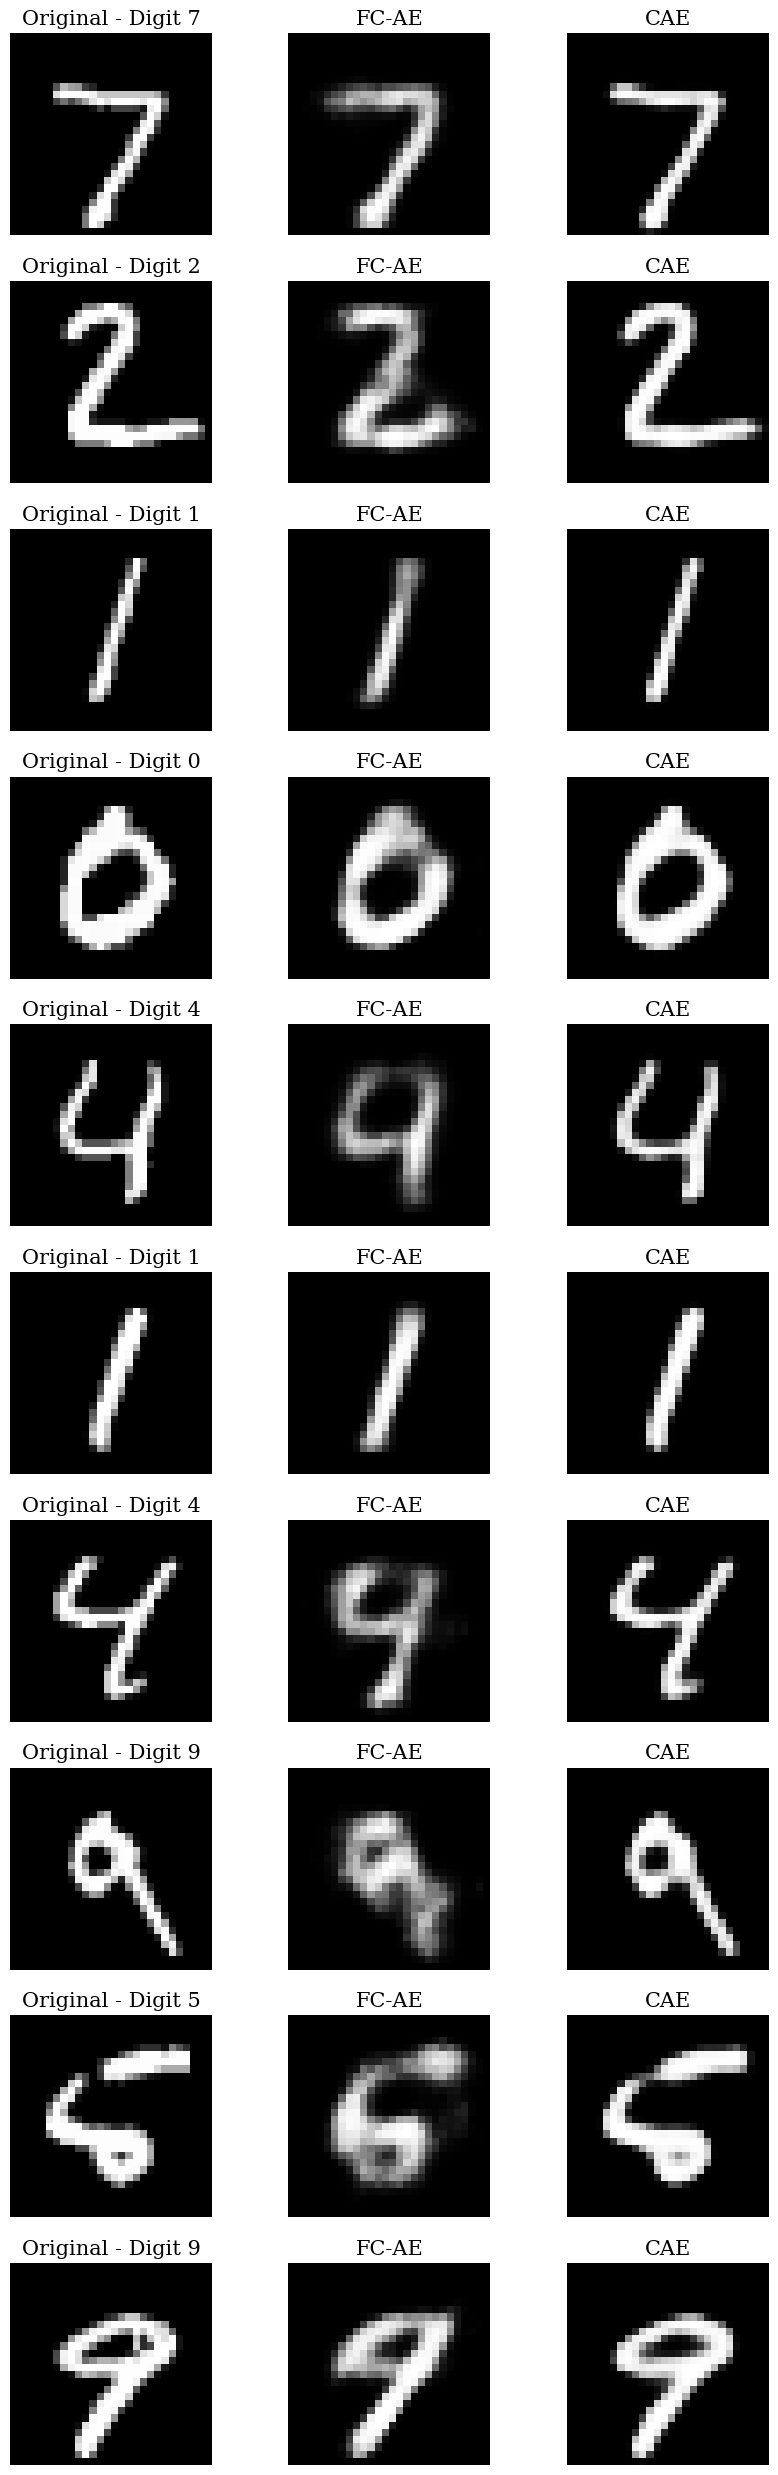

In [ ]:


fig, axes = plt.subplots(10, 3, figsize=(9, 25))

for i in range(10):

    # Original
    axes[i, 0].imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    axes[i, 0].set_title(
        f"Original - Digit {y_test[i]}"
    )
    axes[i, 0].axis("off")

    # FC-AE
    axes[i, 1].imshow(
        fc_reconstructed[i].squeeze(),
        cmap="gray"
    )
    axes[i, 1].set_title("FC-AE")
    axes[i, 1].axis("off")

    # CAE
    axes[i, 2].imshow(
        conv_reconstructed[i].squeeze(),
        cmap="gray"
    )
    axes[i, 2].set_title("CAE")
    axes[i, 2].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_3_original_fc_ae_vs_cae.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:


print("\n" + "=" * 65)
print("FC-AE vs CAE")
print("=" * 65)

print(f"{'Model':<15} {'MSE':<12} {'MAE':<12} {'SSIM':<12} {'Parameters':>15}")
print("-" * 65)

print(
    f"{'FC-AE':<15} "
    f"{fc_test_mse:<12.6f} "
    f"{fc_test_mae:<12.6f} "
    f"{fc_mean_ssim:<12.6f} "
    f"{fc_autoencoder.count_params():>15,}"
)

print(
    f"{'CAE':<15} "
    f"{conv_test_mse:<12.6f} "
    f"{conv_test_mae:<12.6f} "
    f"{conv_mean_ssim:<12.6f} "
    f"{conv_params:>15,}"
)

print("=" * 65)


FC-AE vs CAE
Model           MSE          MAE          SSIM              Parameters
-----------------------------------------------------------------
FC-AE           0.022520     0.059343     0.730456             211,040
CAE             0.002682     0.015420     0.972842              74,497


In [ ]:


def add_gaussian_noise(images, sigma):
    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=images.shape
    )

    noisy_images = images + noise

    # Keep pixel values within [0, 1]
    noisy_images = np.clip(noisy_images, 0.0, 1.0)

    return noisy_images.astype("float32")

In [ ]:
gaussian_noisy_01 = add_gaussian_noise(x_train, 0.1)
gaussian_noisy_02 = add_gaussian_noise(x_train, 0.2)
gaussian_noisy_03 = add_gaussian_noise(x_train, 0.3)

print("σ = 0.1:", gaussian_noisy_01.shape)
print("σ = 0.2:", gaussian_noisy_02.shape)
print("σ = 0.3:", gaussian_noisy_03.shape)

σ = 0.1: (10000, 28, 28, 1)
σ = 0.2: (10000, 28, 28, 1)
σ = 0.3: (10000, 28, 28, 1)


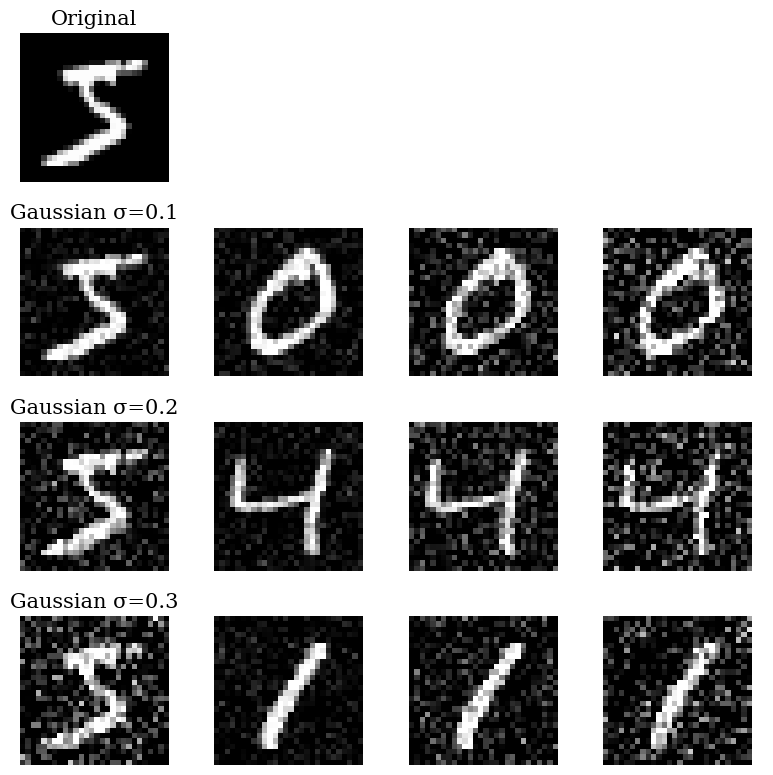

In [ ]:


fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Original
axes[0, 0].imshow(x_train[0].squeeze(), cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Gaussian σ = 0.1
axes[1, 0].imshow(gaussian_noisy_01[0].squeeze(), cmap="gray")
axes[1, 0].set_title("Gaussian σ=0.1")
axes[1, 0].axis("off")

# Gaussian σ = 0.2
axes[2, 0].imshow(gaussian_noisy_02[0].squeeze(), cmap="gray")
axes[2, 0].set_title("Gaussian σ=0.2")
axes[2, 0].axis("off")

# Gaussian σ = 0.3
axes[3, 0].imshow(gaussian_noisy_03[0].squeeze(), cmap="gray")
axes[3, 0].set_title("Gaussian σ=0.3")
axes[3, 0].axis("off")

# Show a few different images as well
for row, idx in enumerate([1, 2, 3], start=1):
    axes[row, 1].imshow(
        gaussian_noisy_01[idx].squeeze(),
        cmap="gray"
    )
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        gaussian_noisy_02[idx].squeeze(),
        cmap="gray"
    )
    axes[row, 2].axis("off")

    axes[row, 3].imshow(
        gaussian_noisy_03[idx].squeeze(),
        cmap="gray"
    )
    axes[row, 3].axis("off")

axes[0, 1].axis("off")
axes[0, 2].axis("off")
axes[0, 3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:


denoising_cae = keras.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),

    # Decoder
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        1, (3, 3),
        activation="sigmoid",
        padding="same"
    )

], name="Denoising_Convolutional_Autoencoder")

denoising_cae.summary()

Model: "Denoising_Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


denoising_cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

In [ ]:


start_time = time.time()

denoise_history = denoising_cae.fit(
    gaussian_noisy_02,
    x_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

denoise_training_time = time.time() - start_time

print(
    f"\nDenoising CAE Training Time: "
    f"{denoise_training_time:.2f} seconds"
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.2793 - val_loss: 0.1328
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1165 - val_loss: 0.1048
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0983 - val_loss: 0.0935
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0912 - val_loss: 0.0913
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0878 - val_loss: 0.0870
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0855 - val_loss: 0.0844
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0836 - val_loss: 0.0837
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0826 - val_loss: 0.0827
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0815 - val_loss: 0.0812
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0806 - val_loss: 0.0807
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0799 - val_loss: 0.0797
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0794 - val_l

In [ ]:


test_noisy_02 = add_gaussian_noise(
    x_test,
    0.2
)

denoised_test = denoising_cae.predict(
    test_noisy_02,
    batch_size=128,
    verbose=1
)

print("Denoised shape:", denoised_test.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Denoised shape: (2000, 28, 28, 1)


In [ ]:

denoise_mse = np.mean(
    (x_test - denoised_test) ** 2
)

denoise_mae = np.mean(
    np.abs(x_test - denoised_test)
)

denoise_ssim_values = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i].squeeze(),
        denoised_test[i].squeeze(),
        data_range=1.0
    )
    denoise_ssim_values.append(score)

denoise_mean_ssim = np.mean(denoise_ssim_values)

denoise_params = denoising_cae.count_params()

print(f"Denoising CAE MSE  : {denoise_mse:.6f}")
print(f"Denoising CAE MAE  : {denoise_mae:.6f}")
print(f"Denoising CAE SSIM : {denoise_mean_ssim:.6f}")
print(f"Denoising CAE Params: {denoise_params:,}")

Denoising CAE MSE  : 0.005072
Denoising CAE MAE  : 0.022050
Denoising CAE SSIM : 0.941061
Denoising CAE Params: 74,497


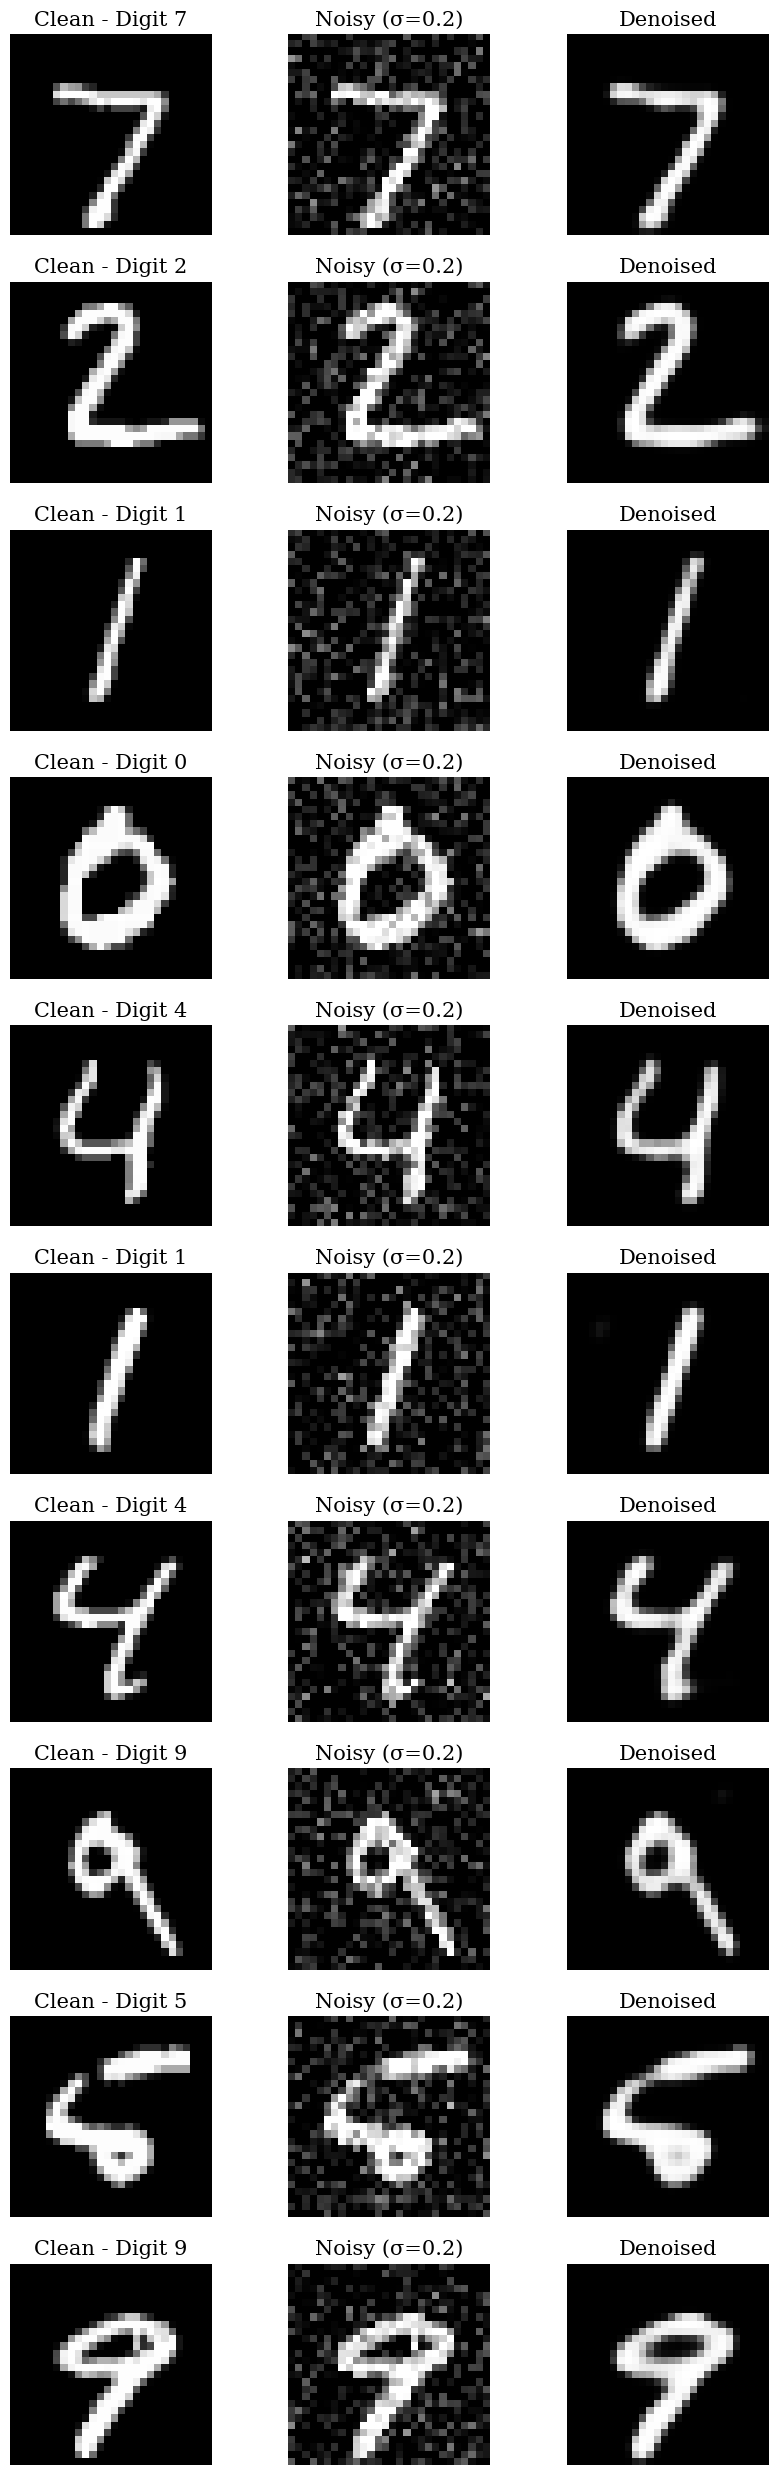

In [ ]:


fig, axes = plt.subplots(
    10, 3,
    figsize=(9, 25)
)

for i in range(10):

    # Clean
    axes[i, 0].imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    axes[i, 0].set_title(
        f"Clean - Digit {y_test[i]}"
    )
    axes[i, 0].axis("off")

    # Noisy
    axes[i, 1].imshow(
        test_noisy_02[i].squeeze(),
        cmap="gray"
    )
    axes[i, 1].set_title("Noisy (σ=0.2)")
    axes[i, 1].axis("off")

    # Denoised
    axes[i, 2].imshow(
        denoised_test[i].squeeze(),
        cmap="gray"
    )
    axes[i, 2].set_title("Denoised")
    axes[i, 2].axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_4_clean_noisy_denoised.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:


noise_levels = [0.1, 0.2, 0.3]

gaussian_results = []

for sigma in noise_levels:

    noisy_test = add_gaussian_noise(
        x_test,
        sigma
    )

    reconstructed = denoising_cae.predict(
        noisy_test,
        batch_size=128,
        verbose=0
    )

    mse = np.mean(
        (x_test - reconstructed) ** 2
    )

    mae = np.mean(
        np.abs(x_test - reconstructed)
    )

    ssim_scores = []

    for i in range(len(x_test)):
        score = ssim(
            x_test[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )
        ssim_scores.append(score)

    mean_ssim = np.mean(ssim_scores)

    gaussian_results.append(
        [sigma, mse, mae, mean_ssim]
    )

    print(
        f"σ={sigma:.1f} | "
        f"MSE={mse:.6f} | "
        f"MAE={mae:.6f} | "
        f"SSIM={mean_ssim:.6f}"
    )

σ=0.1 | MSE=0.004103 | MAE=0.018759 | SSIM=0.956461
σ=0.2 | MSE=0.005051 | MAE=0.021984 | SSIM=0.941483
σ=0.3 | MSE=0.007523 | MAE=0.029951 | SSIM=0.867058


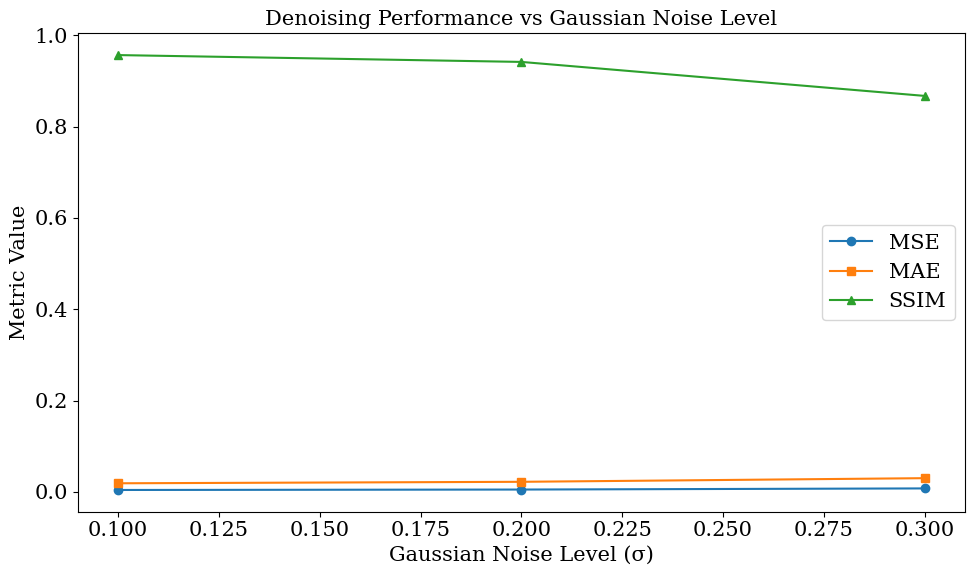

In [ ]:

gaussian_results = np.array(gaussian_results)

sigma_values = gaussian_results[:, 0]
mse_values = gaussian_results[:, 1]
mae_values = gaussian_results[:, 2]
ssim_values = gaussian_results[:, 3]

plt.figure(figsize=(10, 6))

plt.plot(
    sigma_values,
    mse_values,
    marker="o",
    label="MSE"
)

plt.plot(
    sigma_values,
    mae_values,
    marker="s",
    label="MAE"
)

plt.plot(
    sigma_values,
    ssim_values,
    marker="^",
    label="SSIM"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("Metric Value")
plt.title("Denoising Performance vs Gaussian Noise Level")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_5_noise_level_vs_metrics.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:


def add_salt_pepper_noise(images, probability):
    noisy_images = images.copy()

    random_values = np.random.random(images.shape)

    # Salt pixels → 1
    noisy_images[random_values < probability / 2] = 1.0

    # Pepper pixels → 0
    noisy_images[
        (random_values >= probability / 2) &
        (random_values < probability)
    ] = 0.0

    return noisy_images.astype("float32")

In [ ]:
sp_noisy_01 = add_salt_pepper_noise(
    x_test,
    0.05
)

sp_noisy_02 = add_salt_pepper_noise(
    x_test,
    0.10
)

sp_noisy_03 = add_salt_pepper_noise(
    x_test,
    0.20
)

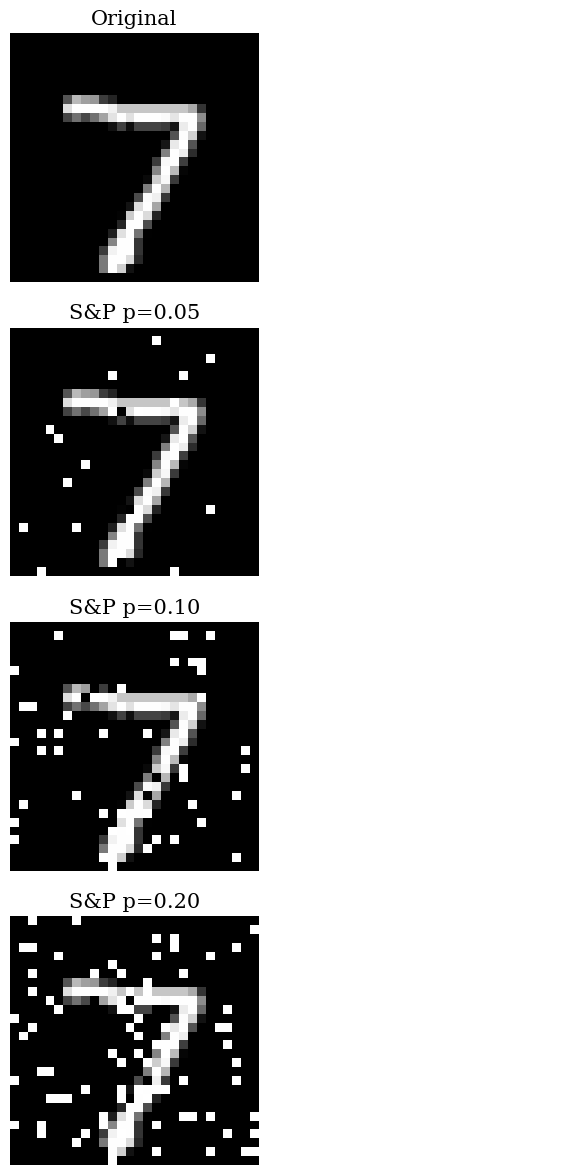

In [ ]:


fig, axes = plt.subplots(4, 2, figsize=(6, 12))

images_to_show = [
    ("Original", x_test[0]),
    ("S&P p=0.05", sp_noisy_01[0]),
    ("S&P p=0.10", sp_noisy_02[0]),
    ("S&P p=0.20", sp_noisy_03[0])
]

for i, (title, image) in enumerate(images_to_show):

    axes[i, 0].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[i, 0].set_title(title)
    axes[i, 0].axis("off")

    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:

LATENT_DIM = 2

encoder_input = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, activation="relu", padding="same")(encoder_input)
x = layers.MaxPooling2D(2, padding="same")(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

encoder = keras.Model(
    encoder_input,
    [z_mean, z_log_var],
    name="VAE_Encoder"
)

encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 7, 7, 64)  │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 7, 7, 64)  │     36,928 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │    401,536 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 457,796 (1.75 MB)

 Trainable params: 457,796 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


decoder_input = keras.Input(shape=(LATENT_DIM,))

x = layers.Dense(7 * 7 * 64, activation="relu")(decoder_input)
x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(
    64, 3, activation="relu", padding="same"
)(x)

x = layers.UpSampling2D(2)(x)

x = layers.Conv2DTranspose(
    32, 3, activation="relu", padding="same"
)(x)

x = layers.UpSampling2D(2)(x)

decoder_output = layers.Conv2D(
    1, 3, activation="sigmoid", padding="same"
)(x)

decoder = keras.Model(
    decoder_input,
    decoder_output,
    name="VAE_Decoder"
)

decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


def sample_latent(z_mean, z_log_var):
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:


class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(
            name="loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs, training=False):
        z_mean, z_log_var = self.encoder(
            inputs,
            training=training
        )

        z = sample_latent(z_mean, z_log_var)

        reconstruction = self.decoder(
            z,
            training=training
        )

        return reconstruction

    def compute_vae_losses(self, data, training=False):

        z_mean, z_log_var = self.encoder(
            data,
            training=training
        )

        z = sample_latent(
            z_mean,
            z_log_var
        )

        reconstruction = self.decoder(
            z,
            training=training
        )

        # Reconstruction loss
        reconstruction_loss = keras.losses.binary_crossentropy(
            data,
            reconstruction
        )

        reconstruction_loss = tf.reduce_sum(
            reconstruction_loss,
            axis=(1, 2)
        )

        reconstruction_loss = tf.reduce_mean(
            reconstruction_loss
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var
            - tf.square(z_mean)
            - tf.exp(z_log_var),
            axis=1
        )

        kl_loss = tf.reduce_mean(kl_loss)

        total_loss = reconstruction_loss + kl_loss

        return (
            total_loss,
            reconstruction_loss,
            kl_loss
        )

    def train_step(self, data):

        with tf.GradientTape() as tape:

            total_loss, reconstruction_loss, kl_loss = \
                self.compute_vae_losses(
                    data,
                    training=True
                )

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        total_loss, reconstruction_loss, kl_loss = \
            self.compute_vae_losses(
                data,
                training=False
            )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

In [ ]:


vae = VAE(
    encoder=encoder,
    decoder=decoder,
    name="Variational_Autoencoder"
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    )
)

print("VAE created successfully.")

VAE created successfully.


In [ ]:


start_time = time.time()

vae_history = vae.fit(
    x_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

vae_training_time = time.time() - start_time

print(f"\nVAE training time: {vae_training_time:.2f} seconds")

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - kl_loss: 5.9860 - loss: 296.5474 - reconstruction_loss: 290.5614 - val_kl_loss: 2.4639 - val_loss: 214.8192 - val_reconstruction_loss: 212.3553
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 2.8664 - loss: 208.0290 - reconstruction_loss: 205.1626 - val_kl_loss: 3.6658 - val_loss: 205.6010 - val_reconstruction_loss: 201.9352
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.3016 - loss: 198.6544 - reconstruction_loss: 195.3528 - val_kl_loss: 3.1764 - val_loss: 195.0836 - val_reconstruction_loss: 191.9072
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.9429 - loss: 183.3372 - reconstruction_loss: 179.3944 - val_kl_loss: 4.5718 - val_loss: 177.3880 - val_reconstruction_loss: 172.8162
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.6246 - loss: 172.6141 - reconstruction_loss: 167.9895 - val_kl_loss: 4.7012 - val_loss: 171.6809 - val_reconstruction_loss: 166.9797
Epoch 6/20
63/63 

In [ ]:

z_mean_test, z_log_var_test = encoder.predict(
    x_test,
    batch_size=128,
    verbose=0
)

vae_reconstructed = decoder.predict(
    z_mean_test,
    batch_size=128,
    verbose=0
)

print(
    "VAE reconstruction shape:",
    vae_reconstructed.shape
)

VAE reconstruction shape: (2000, 28, 28, 1)


In [ ]:


z_mean_test, z_log_var_test = encoder.predict(
    x_test,
    batch_size=128,
    verbose=0
)

vae_reconstructed = decoder.predict(
    z_mean_test,
    batch_size=128,
    verbose=0
)

vae_test_mse = np.mean(
    (x_test - vae_reconstructed) ** 2
)

vae_test_mae = np.mean(
    np.abs(x_test - vae_reconstructed)
)

vae_ssim_values = [
    ssim(
        x_test[i].squeeze(),
        vae_reconstructed[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(x_test))
]

vae_mean_ssim = np.mean(vae_ssim_values)

# Count parameters from encoder + decoder
vae_params = (
    encoder.count_params()
    + decoder.count_params()
)

print(f"VAE Test MSE   : {vae_test_mse:.6f}")
print(f"VAE Test MAE   : {vae_test_mae:.6f}")
print(f"VAE Mean SSIM  : {vae_mean_ssim:.6f}")
print(f"VAE Parameters : {vae_params:,}")
print(f"Training Time  : {vae_training_time:.2f} seconds")

VAE Test MSE   : 0.043338
VAE Test MAE   : 0.101183
VAE Mean SSIM  : 0.491800
VAE Parameters : 522,885
Training Time  : 25.23 seconds


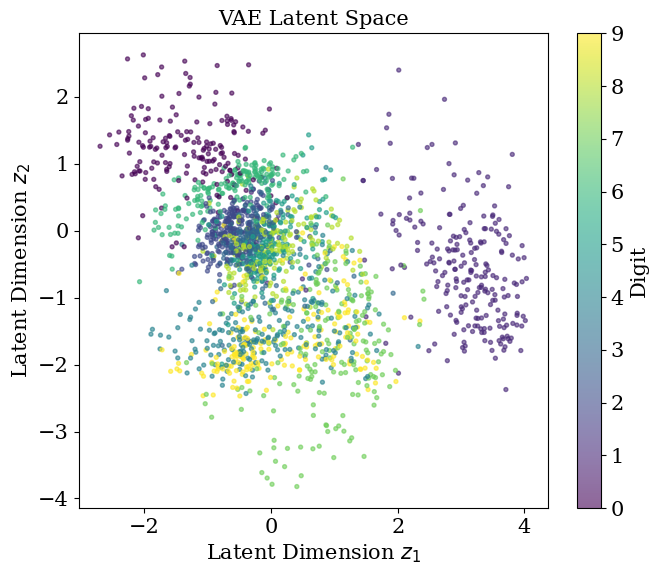

In [ ]:

plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    s=8,
    alpha=0.6
)

plt.xlabel("Latent Dimension $z_1$")
plt.ylabel("Latent Dimension $z_2$")
plt.title("VAE Latent Space")

plt.colorbar(
    scatter,
    label="Digit"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_6_vae_latent_space.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

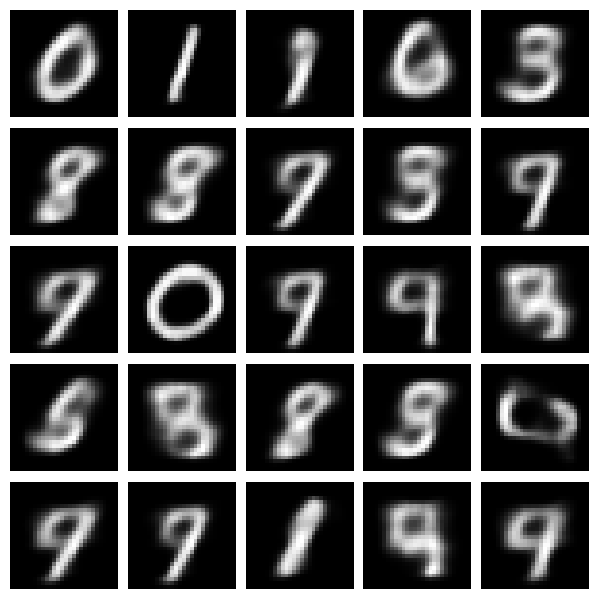

In [ ]:


num_generated = 25

random_latent_vectors = np.random.normal(
    size=(num_generated, LATENT_DIM)
).astype("float32")

generated_images = decoder.predict(
    random_latent_vectors,
    verbose=0
)

plt.figure(figsize=(6, 6))

for i in range(num_generated):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout(pad=0.5)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_7_vae_generated_samples.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

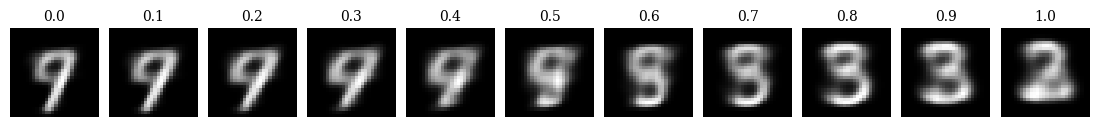

In [ ]:


idx_a = 0
idx_b = 1

z_a = z_mean_test[idx_a]
z_b = z_mean_test[idx_b]

alphas = np.linspace(0, 1, 11)

interpolated_latents = np.array([
    (1 - alpha) * z_a + alpha * z_b
    for alpha in alphas
]).astype("float32")

interpolated_images = decoder.predict(
    interpolated_latents,
    verbose=0
)

plt.figure(figsize=(11, 2))

for i in range(len(alphas)):

    plt.subplot(1, 11, i + 1)

    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"{alphas[i]:.1f}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout(pad=0.5)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_8_vae_latent_interpolation.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

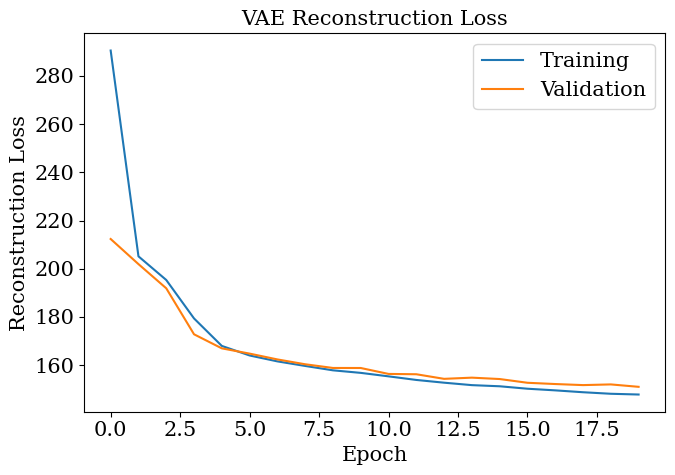

In [ ]:


plt.figure(figsize=(7, 5))

plt.plot(
    vae_history.history["reconstruction_loss"],
    label="Training"
)

plt.plot(
    vae_history.history["val_reconstruction_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("VAE Reconstruction Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_9_vae_training_validation_reconstruction_loss.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:


final_vae_loss = vae_history.history["loss"][-1]
final_reconstruction_loss = \
    vae_history.history["reconstruction_loss"][-1]
final_kl_loss = vae_history.history["kl_loss"][-1]

final_val_vae_loss = vae_history.history["val_loss"][-1]
final_val_reconstruction_loss = \
    vae_history.history["val_reconstruction_loss"][-1]
final_val_kl_loss = \
    vae_history.history["val_kl_loss"][-1]

print(f"Final Training VAE Loss          : {final_vae_loss:.4f}")
print(f"Final Training Reconstruction    : {final_reconstruction_loss:.4f}")
print(f"Final Training KL Loss           : {final_kl_loss:.4f}")

print()

print(f"Final Validation VAE Loss        : {final_val_vae_loss:.4f}")
print(f"Final Validation Reconstruction  : {final_val_reconstruction_loss:.4f}")
print(f"Final Validation KL Loss         : {final_val_kl_loss:.4f}")

Final Training VAE Loss          : 153.4941
Final Training Reconstruction    : 147.8220
Final Training KL Loss           : 5.6721

Final Validation VAE Loss        : 156.9117
Final Validation Reconstruction  : 151.0163
Final Validation KL Loss         : 5.8954


Number of test images: 2000
Mean reconstruction error: 0.043338
Minimum reconstruction error: 0.002769
Maximum reconstruction error: 0.122247


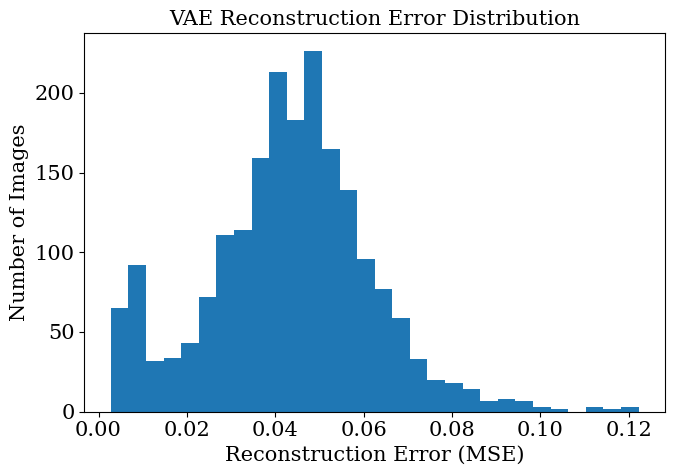

In [ ]:


# Per-image reconstruction error
vae_reconstruction_errors = np.mean(
    (x_test - vae_reconstructed) ** 2,
    axis=(1, 2, 3)
)

print("Number of test images:", len(vae_reconstruction_errors))
print(f"Mean reconstruction error: "
      f"{np.mean(vae_reconstruction_errors):.6f}")
print(f"Minimum reconstruction error: "
      f"{np.min(vae_reconstruction_errors):.6f}")
print(f"Maximum reconstruction error: "
      f"{np.max(vae_reconstruction_errors):.6f}")

# Plot distribution
plt.figure(figsize=(7, 5))

plt.hist(
    vae_reconstruction_errors,
    bins=30
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Number of Images")
plt.title("VAE Reconstruction Error Distribution")

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_10_reconstruction_error_distribution.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:


top_5_indices = np.argsort(
    vae_reconstruction_errors
)[-5:][::-1]

print("Five highest-error test images:\n")

for rank, idx in enumerate(top_5_indices, start=1):
    print(
        f"{rank}. Test index = {idx}, "
        f"Digit = {y_test[idx]}, "
        f"MSE = {vae_reconstruction_errors[idx]:.6f}"
    )

Five highest-error test images:

1. Test index = 1352, Digit = 2, MSE = 0.122247
2. Test index = 654, Digit = 5, MSE = 0.122180
3. Test index = 1847, Digit = 5, MSE = 0.120664
4. Test index = 1325, Digit = 8, MSE = 0.117212
5. Test index = 1790, Digit = 2, MSE = 0.115693


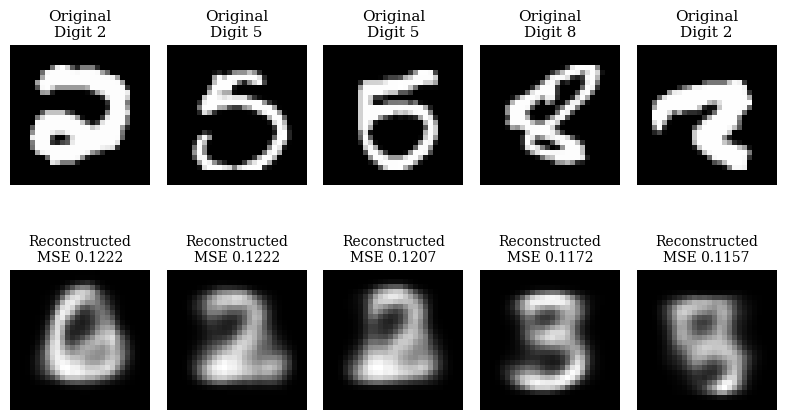

In [ ]:


plt.figure(figsize=(8, 5))

for i, idx in enumerate(top_5_indices):

    # Original
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Original\nDigit {y_test[idx]}",
        fontsize=11
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 5, i + 6)

    plt.imshow(
        vae_reconstructed[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Reconstructed\nMSE {vae_reconstruction_errors[idx]:.4f}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout(pad=0.8)

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "plot_10_highest_error_images.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:


error_mean = np.mean(vae_reconstruction_errors)
error_median = np.median(vae_reconstruction_errors)
error_std = np.std(vae_reconstruction_errors)

print(f"Mean   : {error_mean:.6f}")
print(f"Median : {error_median:.6f}")
print(f"Std    : {error_std:.6f}")
print(f"Min    : {np.min(vae_reconstruction_errors):.6f}")
print(f"Max    : {np.max(vae_reconstruction_errors):.6f}")

Mean   : 0.043338
Median : 0.043813
Std    : 0.018815
Min    : 0.002769
Max    : 0.122247


In [ ]:


print("VAE Loss Summary")
print("-" * 45)

print(
    f"Reconstruction Loss : "
    f"{final_reconstruction_loss:.6f}"
)

print(
    f"KL Loss             : "
    f"{final_kl_loss:.6f}"
)

print(
    f"Total VAE Loss      : "
    f"{final_vae_loss:.6f}"
)

print()

print("Validation Loss Summary")
print("-" * 45)

print(
    f"Validation Reconstruction Loss : "
    f"{final_val_reconstruction_loss:.6f}"
)

print(
    f"Validation KL Loss             : "
    f"{final_val_kl_loss:.6f}"
)

print(
    f"Validation Total Loss          : "
    f"{final_val_vae_loss:.6f}"
)

VAE Loss Summary
---------------------------------------------
Reconstruction Loss : 147.822037
KL Loss             : 5.672087
Total VAE Loss      : 153.494064

Validation Loss Summary
---------------------------------------------
Validation Reconstruction Loss : 151.016327
Validation KL Loss             : 5.895393
Validation Total Loss          : 156.911743


In [ ]:


import shutil
import os

zip_path = shutil.make_archive(
    "lab7_plots",
    "zip",
    "lab7_plots"
)

print("ZIP created successfully:")
print(zip_path)

print("\nFiles included:")
for file in sorted(os.listdir("lab7_plots")):
    print(file)